In [ ]:
import tqdm
import torch
import glob
import networkx as nx
import numpy as np
from collections import Counter, defaultdict

# Gather all graph file paths
dataset = "STF_HC"
train_paths = glob.glob(f"../data/datasets/{dataset}/train/interim/*.pt")
val_paths = glob.glob(f"../data/datasets/{dataset}/validation/interim/*.pt")
test_paths = glob.glob(f"../data/datasets/{dataset}/test/interim/*.pt")

all_paths = train_paths + val_paths + test_paths

metrics = {
    "num_graphs": 0,
    "node_counts": [],
    "edge_counts": [],
    "avg_in_degrees": [],
    "avg_out_degrees": [],
    "clustering_coeffs": [],
    "densities": [],
    "diameters": [],
    "avg_shortest_paths": [],
    "connected_components": [],
    "assortativities": [],
    # new
    "node_type_counter": Counter(),
    "edge_type_counter": Counter()
}

# src/data/visualization.py

import networkx as nx
from pyvis.network import Network
from pathlib import Path
import logging

# A larger, visually distinct color palette for dynamic mapping
PALETTE = [
    "#ff6961", "#ffb480", "#f8f38d", "#42d6a4", "#08cad1", "#59adf6", "#9d94ff", "#c780e8",
    "#ff6b6b", "#f0c419", "#48bb78", "#38b2ac", "#4299e1", "#667eea", "#9f7aea", "#ed64a6",
    "#e53e3e", "#dd6b20", "#d69e2e", "#38a169", "#319795", "#3182ce", "#5a67d8", "#805ad5"
]


def create_dynamic_color_map(items: list) -> dict:
    """Creates a color map for a list of items, cycling through the palette."""
    return {item: PALETTE[i % len(PALETTE)] for i, item in enumerate(items)}


def visualize_dependency_graph(
        graph: nx.MultiDiGraph,
        output_folder: Path,
        doc_id: str,
        label: str
):
    """
    Creates an interactive Pyvis visualization of a dependency graph.

    Nodes are colored by their Part-of-Speech (POS) tag.
    Edges are colored by their dependency relation type.
    """
    output_folder.mkdir(parents=True, exist_ok=True)
    output_filename = output_folder / f"graph_{doc_id}_{label}.html"
    logging.info(f"Creating dependency graph visualization, saving to {output_filename}...")

    # --- 1. Setup Pyvis Network ---
    net = Network(height="900px", width="100%", bgcolor="#222222", font_color="white", notebook=True,
                  cdn_resources='remote', directed=True)

    # --- 2. Dynamically Generate Color Maps ---
    all_pos_tags = sorted(list({data['pos'] for _, data in graph.nodes(data=True) if 'pos' in data}))
    all_dep_labels = sorted(list({data['label'] for _, _, data in graph.edges(data=True) if 'label' in data}))

    pos_color_map = create_dynamic_color_map(all_pos_tags)
    dep_color_map = create_dynamic_color_map(all_dep_labels)

    # --- 3. Add Nodes to the Network ---
    for node_id, data in graph.nodes(data=True):
        lemma = data.get('lemma', 'N/A')
        pos = data.get('pos', 'UNKNOWN')

        title = f"ID: {node_id}\nLemma: {lemma}\nPOS: {pos}"
        node_color = pos_color_map.get(pos, '#E0E0E0')  # Default to grey

        net.add_node(
            node_id,
            label=lemma,
            title=title,
            color=node_color,
            group=pos,
            size=15
        )

    # --- 4. Add Edges to the Network ---
    for u, v, data in graph.edges(data=True):
        dep_label = data.get('label', 'UNKNOWN')
        edge_color = dep_color_map.get(dep_label, '#8D99AE')  # Default to grey

        net.add_edge(
            u, v,
            title=dep_label,
            label=dep_label,
            color=edge_color,
            group=dep_label,
            width=2
        )

    # --- 5. Configure and Save the Graph ---
    net.toggle_physics(True)
    net.show_buttons(filter_=['nodes', 'edges', 'physics'])

    try:
        net.save_graph(str(output_filename))
        logging.info(f"Successfully saved dependency graph to {output_filename}.")
    except Exception as e:
        logging.error(f"Failed to save graph for {doc_id}. Error: {e}")


for path in tqdm.tqdm(all_paths):
    doc_name, label, graph = torch.load(path)
    if not isinstance(graph, nx.MultiDiGraph):
        continue

    visualize_dependency_graph(
        graph=graph,
        output_folder=Path("../data/visualization"),
        doc_id=doc_name,
        label=label
    )

    metrics["num_graphs"] += 1
    n_nodes = graph.number_of_nodes()
    n_edges = graph.number_of_edges()

    metrics["node_counts"].append(n_nodes)
    metrics["edge_counts"].append(n_edges)

    # === Node / edge types collection ===
    for _, data in graph.nodes(data=True):
        if "type" in data:
            metrics["node_type_counter"][data["type"]] += 1
    for _, _, data in graph.edges(data=True):
        if "type" in data:
            metrics["edge_type_counter"][data["type"]] += 1

    # === Degrees ===
    in_degrees = [deg for _, deg in graph.in_degree()]
    out_degrees = [deg for _, deg in graph.out_degree()]
    if in_degrees:
        metrics["avg_in_degrees"].append(np.mean(in_degrees))
    if out_degrees:
        metrics["avg_out_degrees"].append(np.mean(out_degrees))

    # === Clustering Coefficient ===
    undirected_simple = nx.Graph()
    for u, v in graph.edges():
        undirected_simple.add_edge(u, v)
    if undirected_simple.number_of_nodes() > 1:
        try:
            cc = nx.average_clustering(undirected_simple)
            metrics["clustering_coeffs"].append(cc)
        except Exception:
            pass

    # === Density ===
    metrics["densities"].append(nx.density(graph))
    metrics["connected_components"].append(nx.number_weakly_connected_components(graph))

    # === Shortest Path / Diameter ===
    simple_digraph = nx.DiGraph()
    simple_digraph.add_edges_from(graph.edges())
    try:
        if nx.is_weakly_connected(simple_digraph):
            sp = nx.average_shortest_path_length(simple_digraph)
            dia = nx.diameter(simple_digraph.to_undirected())
            metrics["avg_shortest_paths"].append(sp)
            metrics["diameters"].append(dia)
    except Exception:
        pass

    # === Assortativity ===
    try:
        assortativity = nx.degree_assortativity_coefficient(graph)
        if not np.isnan(assortativity):
            metrics["assortativities"].append(assortativity)
    except Exception:
        pass


# === Summary helpers ===
def summarize(values):
    if values:
        arr = np.array(values)
        return f"{np.median(arr):.4f} ± {np.std(arr):.4f}"
    return "N/A"


def top_k(counter, k=10):
    if not counter:
        return "N/A"
    return dict(counter.most_common(k))


summary = {
    "total_graphs": metrics["num_graphs"],
    "nodes per graph (median ± std)": summarize(metrics["node_counts"]),
    "edges per graph (median ± std)": summarize(metrics["edge_counts"]),
    "avg in-degree (median ± std)": summarize(metrics["avg_in_degrees"]),
    "avg out-degree (median ± std)": summarize(metrics["avg_out_degrees"]),
    "avg clustering (median ± std)": summarize(metrics["clustering_coeffs"]),
    "density (median ± std)": summarize(metrics["densities"]),
    "diameter (median ± std)": summarize(metrics["diameters"]),
    "avg shortest path (median ± std)": summarize(metrics["avg_shortest_paths"]),
    "weakly connected components (median ± std)": summarize(metrics["connected_components"]),
    "assortativity (median ± std)": summarize(metrics["assortativities"]),
    # new
    "top node types": top_k(metrics["node_type_counter"]),
    "top edge types": top_k(metrics["edge_type_counter"]),
}

print("\n=== MultiDiGraph Metrics Summary ===")
for key, value in summary.items():
    print(f"{key}: {value}")


  0%|          | 0/1627 [00:00<?, ?it/s]/tmp/ipykernel_108652/1739745900.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  doc_name, label, graph = torch.load(path)
 23%

(array([1.058e+03, 3.050e+02, 8.300e+01, 7.900e+01, 2.900e+01, 4.000e+01,
        2.200e+01, 5.000e+00, 5.000e+00, 1.000e+00]),
 array([ 1. ,  2.6,  4.2,  5.8,  7.4,  9. , 10.6, 12.2, 13.8, 15.4, 17. ]),
 <BarContainer object of 10 artists>)

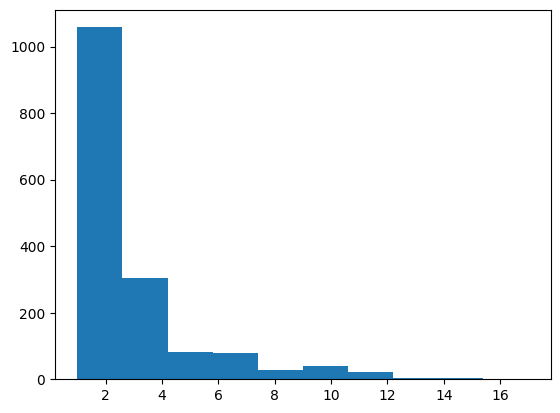

In [7]:
from matplotlib import pyplot as plt

plt.hist(metrics["connected_components"])